# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8932s 52us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

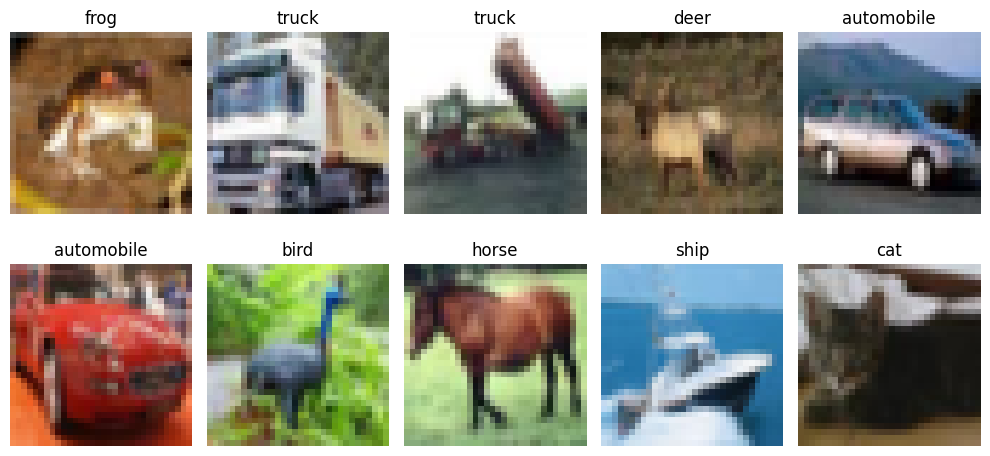

In [7]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [8]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

#Data Augmentation (Beginner Task 5)

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

#Early Stopping (Beginner Task 4)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

#Improved ANN Model (Beginner Task 1)

In [11]:
ann_model = models.Sequential([

    layers.Dense(
        1024,
        activation='relu',
        input_shape=(3072,)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,811,594 (14.54 MB)

 Trainable params: 3,808,522 (14.53 MB)

 Non-trainable params: 3,072 (12.00 KB)

#Train ANN (Epochs = 20) (Beginner Task 3)

In [12]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 73ms/step - accuracy: 0.3052 - loss: 2.0132 - val_accuracy: 0.3130 - val_loss: 1.8489
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.3786 - loss: 1.7328 - val_accuracy: 0.3798 - val_loss: 1.7084
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.4018 - loss: 1.6685 - val_accuracy: 0.3938 - val_loss: 1.7234
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.4095 - loss: 1.6483 - val_accuracy: 0.4118 - val_loss: 1.6378
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.4104 - loss: 1.6476 - val_accuracy: 0.4396 - val_loss: 1.5580
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.4186 - loss: 1.6235 - val_accuracy: 0.4490 - val_loss: 1.5576
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.4202 - loss: 1.6231 - val_accuracy: 0.4518 - val_loss: 1.5478
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.4267 - loss: 1.6080 - 

In [13]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test,verbose=0)
print("ANN Test Accuracy:", ann_test_acc)

ANN Test Accuracy: 0.4733999967575073


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [14]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 125ms/step - accuracy: 0.4712 - loss: 1.4893 - val_accuracy: 0.5040 - val_loss: 1.3530
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.6064 - loss: 1.1258 - val_accuracy: 0.6152 - val_loss: 1.1260
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 130ms/step - accuracy: 0.6670 - loss: 0.9634 - val_accuracy: 0.6658 - val_loss: 0.9587
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 131ms/step - accuracy: 0.7057 - loss: 0.8482 - val_accuracy: 0.6946 - val_loss: 0.8826
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.7406 - loss: 0.7405 - val_accuracy: 0.6750 - val_loss: 0.9593
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.7692 - loss: 0.6636 - val_accuracy: 0.7026 - val_loss: 0.8978
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 130ms/step - accuracy: 0.7906 - loss: 0.5973 - val_accuracy: 0.7274 - val_loss: 0.8256
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 124ms/step - accuracy: 0.8117 - loss

#Improved CNN Model (Beginner Task 2)

In [15]:
cnn_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu'
    ),
    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#Train CNN Model

In [17]:
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 140ms/step - accuracy: 0.4952 - loss: 1.4177 - val_accuracy: 0.5522 - val_loss: 1.2604
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 139ms/step - accuracy: 0.5374 - loss: 1.3012 - val_accuracy: 0.5424 - val_loss: 1.3601
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 139ms/step - accuracy: 0.5695 - loss: 1.2244 - val_accuracy: 0.5642 - val_loss: 1.2150
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 142ms/step - accuracy: 0.5904 - loss: 1.1683 - val_accuracy: 0.6190 - val_loss: 1.0987
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 144ms/step - accuracy: 0.6110 - loss: 1.1093 - val_accuracy: 0.6564 - val_loss: 0.9878
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.6240 - loss: 1.0738 - val_accuracy: 0.6560 - val_loss: 0.9837
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.6367 - loss: 1.0451 - val_accuracy: 0.7000 - val_loss: 0.8676
Epoch 9/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 141ms/step - accuracy: 0.6480 - loss: 1.0158 

In [18]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test,verbose=0)
print("CNN Test Accuracy:", cnn_test_acc)

CNN Test Accuracy: 0.6690000295639038


## 📈 Compare Learning Curves

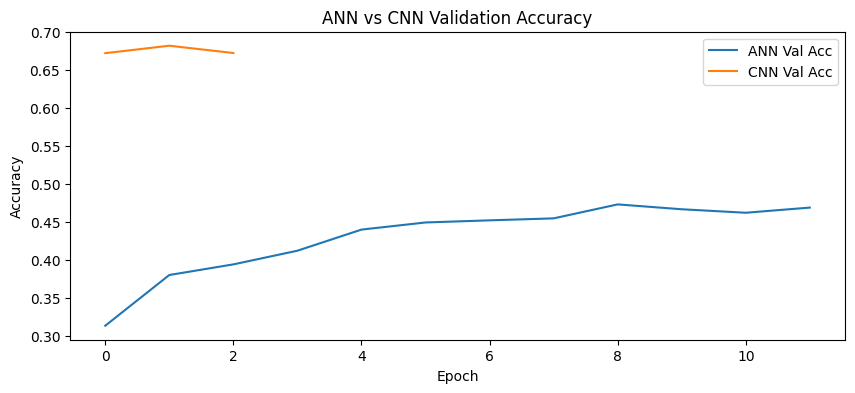

In [19]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

#Validation Accuracy Curve (Requirement 1)

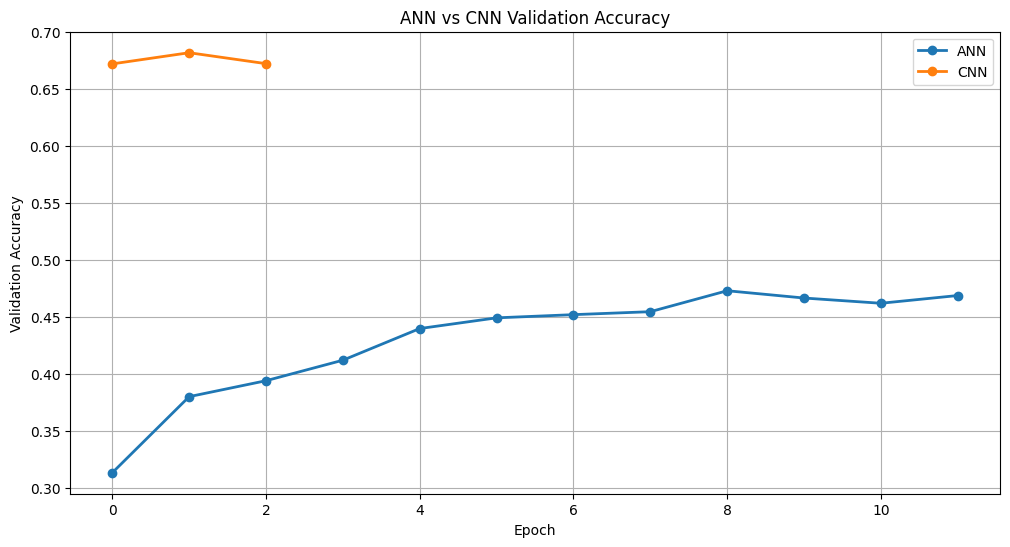

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    ann_history.history['val_accuracy'],
    marker='o',
    linewidth=2,
    label='ANN'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    marker='o',
    linewidth=2,
    label='CNN'
)

plt.title("ANN vs CNN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

#Validation Loss Curve

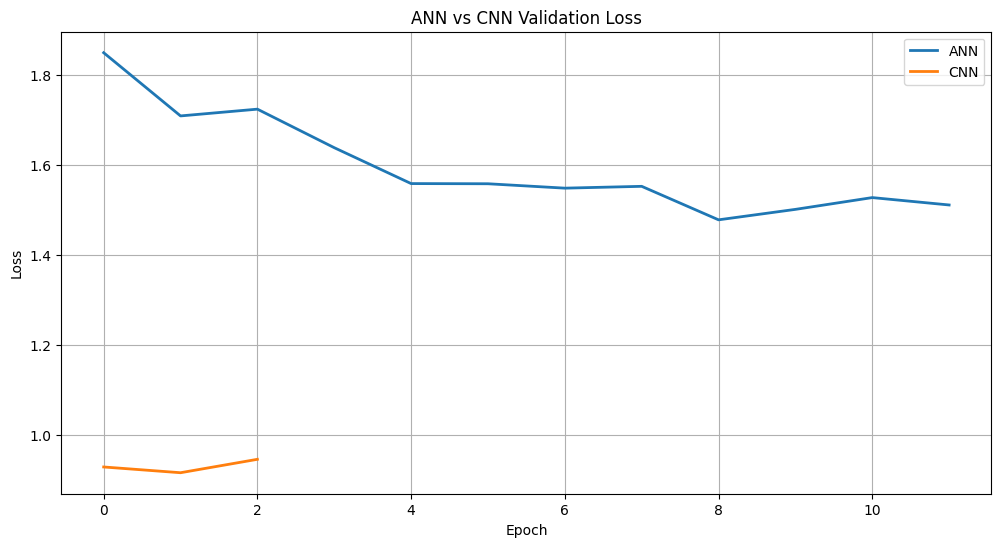

In [21]:
plt.figure(figsize=(12,6))

plt.plot(
    ann_history.history['val_loss'],
    linewidth=2,
    label='ANN'
)

plt.plot(
    cnn_history.history['val_loss'],
    linewidth=2,
    label='CNN'
)

plt.title("ANN vs CNN Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

#Final Comparison DataFrame (Requirement 2)

In [23]:
comparison_df = pd.DataFrame({
    "Model": [
        "Improved ANN",
        "Improved CNN"
    ],
    "Test Accuracy (%)": [
        round(ann_test_acc * 100, 2),
        round(cnn_test_acc * 100, 2)
    ]
})

comparison_df

,Model,Test Accuracy (%)
0,Improved ANN,47.34
1,Improved CNN,66.90


# 📊 Final Comparison Table

In [24]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4734
1,CNN,0.6690


#Rank Models

In [25]:
comparison_df.sort_values(
    by="Test Accuracy (%)",
    ascending=False
)

,Model,Test Accuracy (%)
1,Improved CNN,66.90
0,Improved ANN,47.34


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**